In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
import country_converter as cc

df = pd.read_csv('WHR_2023.csv')
df["Continent"] = cc.convert(names=df["Country name"].tolist(), to="continent")

df

,Country name,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Continent
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363,Europe
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084,Europe
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250,Europe
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691,Asia
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),3.207,0.095,3.394,3.020,7.007,0.652,55.375,0.664,0.086,0.834,1.778,0.531,0.784,0.105,0.375,0.183,0.068,1.162,Africa
133,Zimbabwe,3.204,0.061,3.323,3.084,7.641,0.690,54.050,0.654,-0.046,0.766,1.778,0.758,0.881,0.069,0.363,0.112,0.117,0.905,Africa
134,Sierra Leone,3.138,0.082,3.299,2.976,7.394,0.555,54.900,0.660,0.105,0.858,1.778,0.670,0.540,0.092,0.371,0.193,0.051,1.221,Africa
135,Lebanon,2.392,0.044,2.479,2.305,9.478,0.530,66.149,0.474,-0.141,0.891,1.778,1.417,0.476,0.398,0.123,0.061,0.027,-0.110,Asia


In [16]:
print(df.duplicated(subset=['Country name']).sum())


0


In [17]:
print(df.isna().sum())

Country name                                  0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       1
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         1
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           1
Continent                                     0
dtype: int64


In [18]:
df['Healthy life expectancy'] = df['Healthy life expectancy'].fillna(df['Healthy life expectancy'].mean(), inplace=True)
df['Freedom to make life choices'] = df['Freedom to make life choices'].fillna(df['Freedom to make life choices'].mean(), inplace=True)
print(df.isna().sum())

Country name                                  0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       0
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         1
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           1
Continent                                     0
dtype: int64


/var/folders/fw/3wj_tsl565q3h89yd5sjvj4h0000gn/T/ipykernel_42929/1205103001.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Healthy life expectancy'] = df['Healthy life expectancy'].fillna(df['Healthy life expectancy'].mean(), inplace=True)
/var/folders/fw/3wj_tsl565q3h89yd5sjvj4h0000gn/T/ipykernel_42929/1205103001.py:2: Chai

<function matplotlib.pyplot.show(close=None, block=None)>

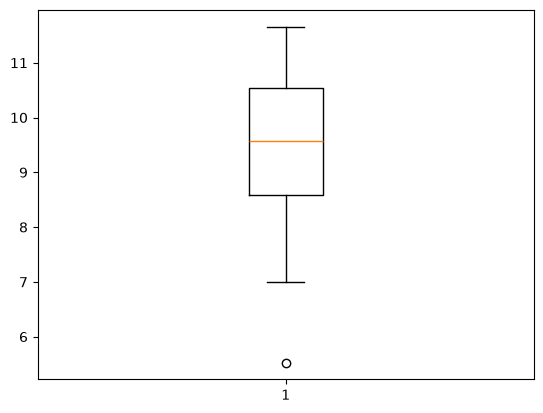

In [19]:
plt.boxplot(df['Logged GDP per capita'])
plt.show

In [20]:
Q1 = df['Logged GDP per capita'].quantile(0.25)
Q3 = df['Logged GDP per capita'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [21]:
df = df[(df['Logged GDP per capita'] >= lower_bound) & (df['Logged GDP per capita'] <= upper_bound)]

outlier = df[(df['Logged GDP per capita'] < lower_bound) | (df['Logged GDP per capita'] > upper_bound)]
outlier_count = outlier.sum()

print("Number of outliers removed:", outlier_count)

Number of outliers removed: Country name                                     
Ladder score                                  0.0
Standard error of ladder score                0.0
upperwhisker                                  0.0
lowerwhisker                                  0.0
Logged GDP per capita                         0.0
Social support                                0.0
Healthy life expectancy                       0.0
Freedom to make life choices                  0.0
Generosity                                    0.0
Perceptions of corruption                     0.0
Ladder score in Dystopia                      0.0
Explained by: Log GDP per capita              0.0
Explained by: Social support                  0.0
Explained by: Healthy life expectancy         0.0
Explained by: Freedom to make life choices    0.0
Explained by: Generosity                      0.0
Explained by: Perceptions of corruption       0.0
Dystopia + residual                           0.0
Continent             

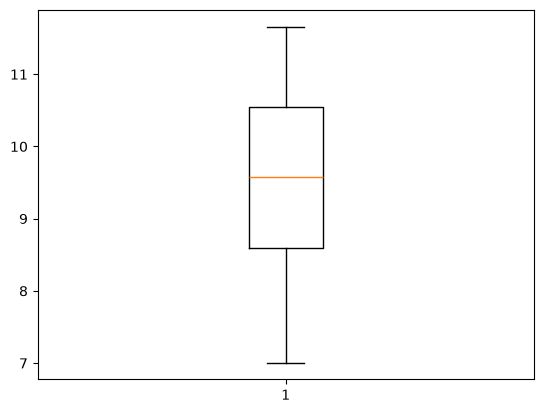

In [22]:
plt.boxplot(df['Logged GDP per capita'])
plt.show()

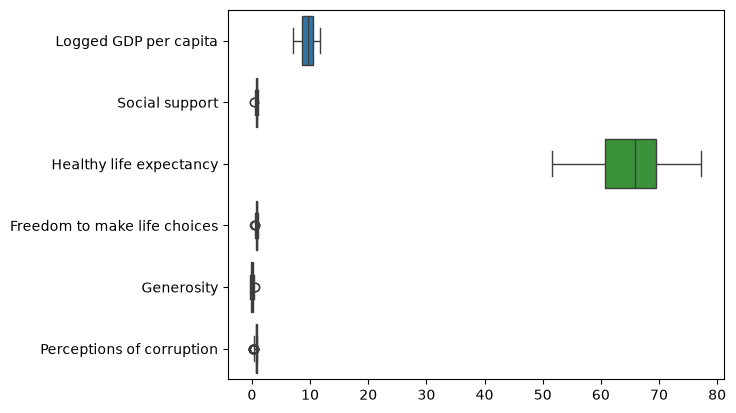

In [23]:
cols = ['Logged GDP per capita',
        'Social support',
        'Healthy life expectancy',
        'Freedom to make life choices',
        'Generosity',
        'Perceptions of corruption'
        ]

sns.boxplot(data=df[cols], orient='h')
plt.show()

[[ 1.13305050e+00  1.31773646e+00  1.07802069e+00  1.54401481e+00
  -2.87482851e-01 -3.06993680e+00]
 [ 1.27971138e+00  1.20161627e+00  1.09547677e+00  1.30256935e+00
   7.94438504e-01 -2.99075234e+00]
 [ 1.22277245e+00  1.42611530e+00  1.23512534e+00  1.32045420e+00
   1.33893487e+00 -3.21104651e-01]
 [ 1.00105570e+00  1.11646147e+00  1.34806612e+00  1.84766273e-01
  -3.15768377e-01 -9.48633220e-02]
 [ 1.26245716e+00  1.01582397e+00  1.14784498e+00  8.82275391e-01
   1.35307763e+00 -1.95569825e+00]
 [ 1.21155721e+00  1.08549608e+00  1.25258141e+00  1.42776329e+00
   1.01365133e+00 -2.95681614e+00]
 [ 1.38841298e+00  1.11646147e+00  1.13911694e+00  1.41882087e+00
   8.43938174e-01 -2.49867744e+00]
 [ 1.45397903e+00  9.38410510e-01  1.38350194e+00  9.18045089e-01
   3.78006933e-02 -2.59483001e+00]
 [ 1.88188373e+00  6.21015326e-01  1.16966507e+00  1.13266328e+00
   1.65865490e-02 -2.14800338e+00]
 [ 1.02089806e+00  1.18613358e+00  9.38372124e-01  8.82275391e-01
   1.08436514e+00 -2.5665

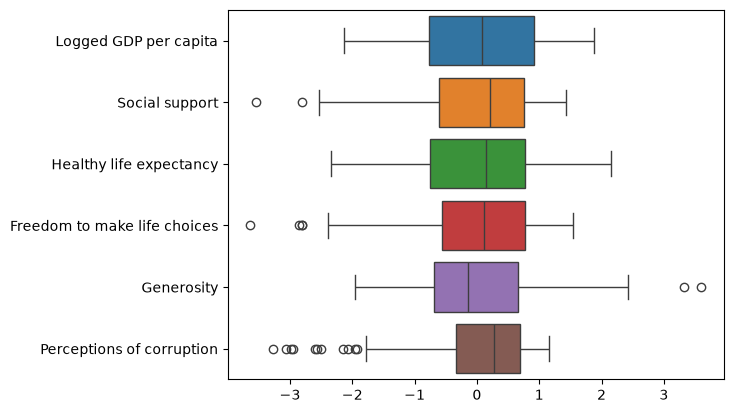

In [24]:
scaler = StandardScaler()

print(scaler.fit_transform(df[cols]))

df = pd.DataFrame(scaler.fit_transform(df[cols]), columns=cols)

sns.boxplot(data=df[cols], orient='h')
plt.show()

In [ ]:
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df[cols] >= lower_bound) & (df[cols] <= upper_bound)]
outlier = df[(df[cols] < lower_bound) | (df[cols] > upper_bound)]
outlier_count = outlier.sum()
print("Number of outliers removed:", outlier_count)

sns.boxplot(data=df[cols], orient='h', palette='Set2') 
plt.title('Boxplot')
plt.xlabel('Values')
plt.show()

AttributeError: 'DataFrame' object has no attribute 'between'